In [124]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [125]:
def f(x):
    return 3*x**2 - 4*x + 5

In [126]:
f(3.0)

20.0

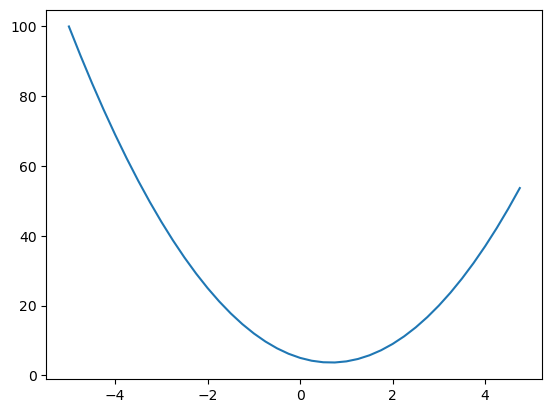

In [127]:
x_train = np.arange(-5, 5, 0.25)
y_train = f(x_train)
plt.plot(x_train, y_train)

In [128]:
h = 0.000001
x_train = 2/3
f(x_train), f(x_train + h)

derivative = (f(x_train + h) - f(x_train)) / h
print(f"derivative = {derivative}")

derivative = 2.999378523327323e-06


In [129]:
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print(f"derivative wrt a = {(d2 - d1) / h}")
a -= h

d1 = a*b + c
b += h
d2 = a*b + c

print(f"derivative wrt b = {(d2 - d1) / h}")
b -= h

d1 = a*b + c
c += h
d2 = a*b + c

print(f"derivative wrt c = {(d2 - d1) / h}")

derivative wrt a = -3.000000000419334
derivative wrt b = 2.000000000279556
derivative wrt c = 0.9999999992515995


In [130]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [131]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

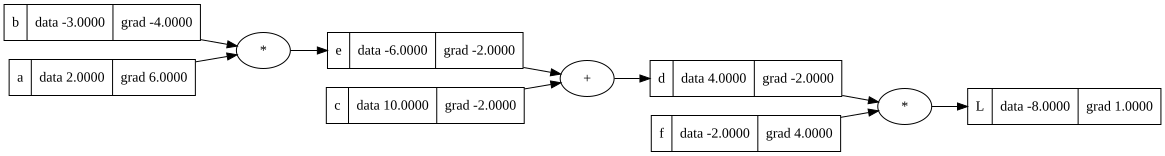

In [132]:
def loss():
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    return L

L = loss()
draw_dot(L)
L.backward()
draw_dot(L)

In [133]:
# Verifying results.
h = 0.001

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

l1 = L.data
print(l1)

a = Value(2.0, label='a')
b = Value(-3.0 + h, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

l2 = L.data
print(l2)

print(f"derivative wrt changed val = {(l2 - l1) / h}")

-8.0
-8.004
derivative wrt changed val = -3.9999999999995595


In [134]:
import torch
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(-3.0, requires_grad=True)
c = torch.tensor(10.0, requires_grad=True)
e = a * b
d = e + c
f = torch.tensor(-2.0, requires_grad=True)
L = d * f

print(L.item())
L.backward()

print(f"gradient for a = {a.grad}")
print(f"gradient for b = {b.grad}")
print(f"gradient for c = {c.grad}")
print(f"gradient for d = {d.grad}")
print(f"gradient for e = {e.grad}")
print(f"gradient for f = {f.grad}")
print(f"gradient for L = {L.grad}")


-8.0
gradient for a = 6.0
gradient for b = -4.0
gradient for c = -2.0
gradient for d = None
gradient for e = None
gradient for f = 4.0
gradient for L = None


C:\Users\Nitin\AppData\Local\Temp\ipykernel_21536\321635387.py:16: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at C:\b\abs_fakvb73nko\croot\pytorch-select_1730848725921\work\build\aten\src\ATen/core/TensorBody.h:494.)
  print(f"gradient for d = {d.grad}")
C:\Users\Nitin\AppData\Local\Temp\ipykernel_21536\321635387.py:17: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Te

In [135]:
import random

class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

x_train = [2.0, 3.0]
model = Neuron(2)
model(x_train)

Value(data=0.5848002989489622)

In [ ]:
class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MultiLayerPerceptronNN:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

x_train = [2.0, 3.0, -1.0]
model = MultiLayerPerceptronNN(3, [4, 4, 1])
model(x_train)

Value(data=0.40830730752215166)

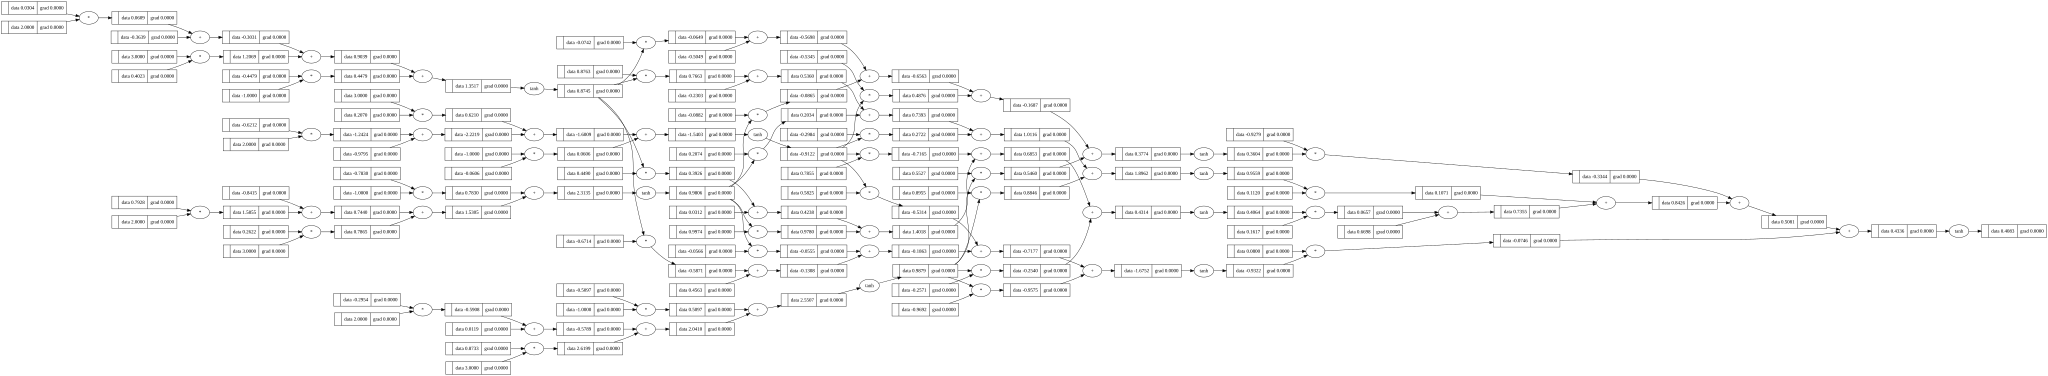

In [137]:
draw_dot(model(x_train))

In [138]:
x_train = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
y_train = [1.0, -1.0, -1.0, 1.0] # desired targets

y_pred = [model(x) for x in x_train]
print(y_pred)

[Value(data=0.40830730752215166), Value(data=0.7865677529911772), Value(data=0.34472844411186804), Value(data=0.42046210156253605)]


In [139]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(y_train, y_pred))
print(loss)


Value(data=5.686083342488468)


In [142]:
for k in range(20):
  
  # forward pass
  y_pred = [model(x) for x in x_train]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(y_train, y_pred))
  
  # backward pass
  for p in model.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in model.parameters():
    p.data += -0.1 * p.grad
  
  print(f"loss at epoch {k} = {loss.data}")
  
  
y_pred = [model(x) for x in x_train]
print(y_train, y_pred)

loss at epoch 0 = 0.0046979568938757075
loss at epoch 1 = 0.004576645434754653
loss at epoch 2 = 0.004461273454199429
loss at epoch 3 = 0.0043514204198765605
loss at epoch 4 = 0.004246704309499849
loss at epoch 5 = 0.004146777321198235
loss at epoch 6 = 0.004051322142953995
loss at epoch 7 = 0.0039600486981095475
loss at epoch 8 = 0.00387269129770826
loss at epoch 9 = 0.003789006141685641
loss at epoch 10 = 0.003708769120166597
loss at epoch 11 = 0.0036317738737425558
loss at epoch 12 = 0.003557830077907506
loss at epoch 13 = 0.003486761922072367
loss at epoch 14 = 0.0034184067579478123
loss at epoch 15 = 0.0033526138957440397
loss at epoch 16 = 0.003289243529708291
loss at epoch 17 = 0.003228165777110535
loss at epoch 18 = 0.0031692598169756094
loss at epoch 19 = 0.0031124131167165952
[1.0, -1.0, -1.0, 1.0] [Value(data=0.9877730686381389), Value(data=-0.97887945583283), Value(data=-0.9626362405580423), Value(data=0.9673519528865788)]
